# Data cleaning - Traing with word2vec

In [1]:
6+6

12

In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raw_data = pd.read_csv('../dataset/data.csv')
print(raw_data.shape)
#raw_data = raw_data.head(1000)
raw_data = raw_data.drop(columns=['subject', 'date'])
print(raw_data.shape)
raw_data

(39942, 5)
(39942, 3)


,label,title,text
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...
...,...,...,...
39937,0,THIS IS NOT A JOKE! Soros-Linked Group Has Pla...,"The Left has been organizing for decades, and ..."
39938,0,THE SMARTEST WOMAN In Politics: “How Trump Can...,Monica Crowley offers some of the most brillia...
39939,0,BREAKING! SHOCKING VIDEO FROM CHARLOTTE RIOTS:...,Protest underway in Charlotte: Things got com...
39940,0,BREAKING! Charlotte News Station Reports Cops ...,"Local Charlotte, NC news station WSOCTV is rep..."


In [4]:
raw_data.columns

Index(['label', 'title', 'text'], dtype='str')

#data cleaning

In [5]:
# Your code
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
# Your code
from sklearn.model_selection import train_test_split

# Your code
import re

In [6]:
# Features (emails)
X = raw_data.drop(columns='label')
# Labels (0 = legitimate, 1 = fraudulent)
y = raw_data["label"]

# Split the raw_dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y      # Keeps the same class distribution
)

In [7]:
def clean_data(text):
    # 1. Remove inline JavaScript
    text = re.sub(r'<script.*?>.*?</script>', '', text, flags=re.DOTALL | re.IGNORECASE)

    # 2. Remove inline CSS
    text = re.sub(r'<style.*?>.*?</style>', '', text, flags=re.DOTALL | re.IGNORECASE)

    # 3. Remove HTML comments
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)

    # 4. Remove all remaining HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLS
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove all the special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove all single characters
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)

    # Remove single characters from the start
    text = re.sub(r'^\s*[a-zA-Z]\s+', '', text)

    # Substitute multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)

    # Remove prefixed 'b'
    text = re.sub(r'^b\s+', '', text)

    # Convert to Lowercase
    text = text.lower()

    return text


In [8]:
# X_train['clean_title'] = X_train['title'].apply(clean_data)
# X_train['clean_text'] = X_train['text'].apply(clean_data)

# X_test['clean_title'] = X_test['title'].apply(clean_data)
# X_test['clean_text'] = X_test['text'].apply(clean_data)

# X_train

In [9]:
def preprocess_data(text):
    # Tokenize the email
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    filtered_tokens = []

    for word in tokens:
        if word.lower() not in stop_words:
            filtered_tokens.append(word)
    
    # Lemmetization
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens ] 

    # Join the tokens back into a string
    return " ".join(lemmatized_tokens)

In [10]:
# X_train['clean_title_prerocessed'] = X_train['clean_title'].apply(preprocess_data)
# X_train['clean_text_prerocessed'] = X_train['clean_text'].apply(preprocess_data)

# X_test['clean_title_prerocessed'] = X_test['clean_title'].apply(preprocess_data)
# X_test['clean_text_prerocessed'] = X_test['clean_text'].apply(preprocess_data)

# X_train

In [11]:
# X_train_clean = X_train[['clean_title_prerocessed', 'clean_text_prerocessed']]
# X_train_clean.columns = ['title', 'text']

# X_test_clean = X_test[['clean_title_prerocessed', 'clean_text_prerocessed']]
# X_test_clean.columns = ['title', 'text']

# X_train_clean

In [12]:
# X_train_clean.to_csv('X_train_clean.csv')
# X_test_clean.to_csv('X_test_clean.csv')

# read train and test

In [13]:
X_train_clean = pd.read_csv('X_train_clean.csv', index_col=0)
X_test_clean = pd.read_csv('X_test_clean.csv', index_col=0)

X_train_clean

,title,text
33231,must see house oversight committee release dam...,crooked lying hillary
36761,scalia found dead pillow head millionaire demo...,justice scalia appeared good health prior vaca...
29035,road raging texas good guy gun shoot woman hea...,university north texas student critical condit...
31791,firebenstein fox news ben stein call president...,NaN
3419,exclusive special counsel mueller probe ex tru...,washington reuters robert mueller special coun...
...,...,...
33001,radical anti gun muslim state senator arrested...,october radical muslim state senator jamilah r...
13185,german police check suspicious parcel potsdam ...,berlin reuters german police monday investigat...
1334,mexico remain nafta good national interest for...,mexico city reuters mexico remain within north...
32958,trump falsely accused encouraging police racia...,trump actually said police amazing local polic...


In [14]:
any(y_train.index == X_train.index)

True

In [15]:
X_train_clean.isna().sum()

title      5
text     549
dtype: int64

In [16]:
X_test_clean.isna().sum()

title      2
text     144
dtype: int64

In [17]:
X_train_clean.loc[35507,:]

title    NaN
text     NaN
Name: 35507, dtype: str

## Fill null values with empty string ' '
- after cleaning and preprocessing text - null values foound.
- fill with empty strings

In [18]:
X_train_clean = X_train_clean.fillna('')
X_test_clean = X_test_clean.fillna('')

X_train_clean.isna().sum().sum(), X_test_clean.isna().sum().sum()

(np.int64(0), np.int64(0))

In [19]:
k

NameError: name 'k' is not defined

In [20]:
X_train_clean.isna().sum().sum(), X_test_clean.isna().sum().sum()

(np.int64(0), np.int64(0))

# word2vec

In [23]:
from gensim.models import Word2Vec

In [ ]:
TEXT_COLUMNS = ['title', 'text']

def get_avg_vector(text, model, dim=100):
    words = text.split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(dim)


# --- TF-IDF per text column ---
w2v_vectorizers = {}
X_train_text_features = []
X_test_text_features = []

for col in TEXT_COLUMNS:
    train_tokens = X_train_clean[col].apply(lambda t: t.split())
    w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2, sg=1)

    train_vec = np.vstack(X_train_clean[col].apply(lambda t: get_avg_vector(t, w2v_model)))
    test_vec = np.vstack(X_test_clean[col].apply(lambda t: get_avg_vector(t, w2v_model)))

    w2v_vectorizers[col] = w2v_model
    X_train_text_features.append(train_vec)
    X_test_text_features.append(test_vec)

    print(f"{col}: train shape {train_vec.shape}, test shape {test_vec.shape}")


title: train shape (31953, 100), test shape (7989, 100)
text: train shape (31953, 100), test shape (7989, 100)


In [26]:
w2v_vectorizers['text']

KeyError: 'text'

In [27]:
# --- Combine all features ---
X_train_final = np.hstack(X_train_text_features)
X_test_final = np.hstack(X_test_text_features)

print("Final train feature matrix:", X_train_final.shape)
print("Final test feature matrix:", X_test_final.shape)

Final train feature matrix: (31953, 200)
Final test feature matrix: (7989, 200)


<!-- ### 8.1 Word2Vec Features (pseudocode)

```python
from gensim.models import Word2Vec
import numpy as np

# 1. Tokenize cleaned text (train only, to "fit" the model)
train_tokens = [text.split() for text in X_train['title_clean'] + " " + X_train['description_clean']]

# 2. Train Word2Vec on training tokens only (or load a pretrained model, e.g. Google News vectors)
w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=1, sg=1)

# 3. Helper: average word vectors to get one fixed-size vector per document
def get_avg_vector(text, model, dim=100):
    words = text.split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(dim)

# 4. Apply to train and test SEPARATELY (reuse the same fitted w2v_model — do not refit on test)
X_train_w2v = np.vstack(X_train['title_clean'].apply(lambda t: get_avg_vector(t, w2v_model)))
X_test_w2v  = np.vstack(X_test['title_clean'].apply(lambda t: get_avg_vector(t, w2v_model)))

# repeat for description column, then combine with country OHE:
# X_train_final_w2v = np.hstack([X_train_w2v_title, X_train_w2v_desc, X_train_cat.toarray()])
# X_test_final_w2v  = np.hstack([X_test_w2v_title,  X_test_w2v_desc,  X_test_cat.toarray()])

# 5. Train/evaluate using the SAME framework as before
# lr_w2v = LogisticRegression(max_iter=1000)
# _ = train_evaluate_model(
#     lr_w2v, "Logistic Regression",
#     X_train_final_w2v, y_train, X_test_final_w2v, y_test,
#     comments="Word2Vec (avg) + OneHot",
#     results_container=results
# )
``` -->


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## model training

## reusable function

In [29]:
import json
import os
from datetime import datetime

RESULTS_FILE = "results_log.jsonl"   # one JSON object per line, easy to append to


def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Predict on train and test data and compute evaluation metrics.
    Returns a dict of metrics + the confusion matrix (test-based).
    """
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred, zero_division=0),
        'recall': recall_score(y_test, y_test_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_test_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_test_pred),
        'y_pred': y_test_pred,
    }
    return metrics


def save_result_to_file(result, filepath=RESULTS_FILE):
    """
    Append a single result to a JSONL file (one JSON object per line).
    Excludes non-serializable objects (fitted model, y_pred array).
    Safe to call repeatedly — appends, never overwrites.
    """
    serializable_result = {
        'timestamp': result['timestamp'],
        'model_name': result['model_name'],
        'method': result['method'],
        'comments': result['comments'],
        'train_accuracy': result['train_accuracy'],
        'test_accuracy': result['test_accuracy'],
        'precision': result['precision'],
        'recall': result['recall'],
        'f1_score': result['f1_score'],
        'confusion_matrix': result['confusion_matrix'].tolist(),  # np.array -> list for JSON
    }

    with open(filepath, 'a') as f:
        f.write(json.dumps(serializable_result) + "\n")


def train_evaluate_model(model, method, model_name, X_train, y_train, X_test, y_test,
                          comments="", results_container=None,
                          save_to_file=True, filepath=RESULTS_FILE):
    """
    Super-function: trains, predicts, evaluates, and optionally stores results
    in-memory (results_container) and/or on disk (filepath), so results persist
    across notebook restarts.

    Parameters
    ----------
    model : sklearn-like estimator (must implement .fit and .predict)
    model_name : str, name/label for this run (e.g. "Logistic Regression")
    method : str, feature-extraction method used (e.g. "TF-IDF")
    comments : str, free-text notes (e.g. hyperparameters, feature set used)
    results_container : list, optional. If provided, the result dict is appended to it.
    save_to_file : bool, whether to append this result to disk immediately (default True)
    filepath : str, path to the JSONL results log file

    Returns
    -------
    result : dict with keys:
        timestamp, model_name, method, comments, train_accuracy, test_accuracy,
        precision, recall, f1_score, confusion_matrix, model (fitted object)
    """
    fitted_model = model.fit(X_train, y_train)
    metrics = evaluate_model(fitted_model, X_train, y_train, X_test, y_test)

    result = {
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'model_name': model_name,
        'method': method,
        'comments': comments,
        'train_accuracy': metrics['train_accuracy'],
        'test_accuracy': metrics['test_accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1_score': metrics['f1_score'],
        'confusion_matrix': metrics['confusion_matrix'],
        'model': fitted_model,
    }

    print(f"--- {model_name} | {method} ({comments}) ---")
    print(f"Train Accuracy: {result['train_accuracy']:.4f}")
    print(f"Test Accuracy:  {result['test_accuracy']:.4f}")
    print(f"Precision:      {result['precision']:.4f}")
    print(f"Recall:         {result['recall']:.4f}")
    print(f"F1 Score:       {result['f1_score']:.4f}")
    print("Confusion Matrix:\n", result['confusion_matrix'])
    print()

    if results_container is not None:
        results_container.append(result)

    if save_to_file:
        save_result_to_file(result, filepath=filepath)

    return result


def load_results_from_file(filepath=RESULTS_FILE):
    """Load all saved results from the JSONL file into a DataFrame."""
    if not os.path.exists(filepath):
        return pd.DataFrame()

    records = []
    with open(filepath, 'r') as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

# usage:
# results_df = load_results_from_file()
# results_df.sort_values('f1_score', ascending=False)

## train models


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC


In [31]:
print(X_train_final.shape, y_train.shape)
print(X_test_final.shape, y_test.shape)

(31953, 200) (31953,)
(7989, 200) (7989,)


In [32]:
# Container to collect results from every model we try below
RESULTS = []


In [33]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_results = train_evaluate_model(
    lr_model, 'Word2Vec', 'Logistic Regression - Word2Vec',
    X_train_final, y_train, X_test_final, y_test,
    comments="Baseline LR model with word2vec(100 dims, sg=1)", 
    results_container=RESULTS
    )

--- Logistic Regression - Word2Vec | Word2Vec (Baseline LR model with word2vec(100 dims, sg=1)) ---
Train Accuracy: 0.9776
Test Accuracy:  0.9776
Precision:      0.9785
Recall:         0.9768
F1 Score:       0.9776
Confusion Matrix:
 [[3903   86]
 [  93 3907]]



In [36]:
# nb_model = MultinomialNB()
# nb_results = train_evaluate_model(
#     nb_model, 'Word2Vec', 'Naive Bayes - Word2Vec',
#     X_train_final, y_train, X_test_final, y_test,
#     comments="Naive Bayes model with word2vec(100 dims, sg=1)", 
#     results_container=RESULTS
#     )

In [34]:
svm_model = LinearSVC()
svm_results = train_evaluate_model(
    svm_model, 'Word2Vec', 'SVM - Word2Vec',
    X_train_final, y_train, X_test_final, y_test,
    comments="SVM model with word2vec(100 dims, sg=1)", 
    results_container=RESULTS
    )

--- SVM - Word2Vec | Word2Vec (SVM model with word2vec(100 dims, sg=1)) ---
Train Accuracy: 0.9830
Test Accuracy:  0.9810
Precision:      0.9820
Recall:         0.9800
F1 Score:       0.9810
Confusion Matrix:
 [[3917   72]
 [  80 3920]]



In [ ]:
# rf_model = RandomForestClassifier(random_state=42)
# rf_results = train_evaluate_model(
#     rf_model, 'Word2Vec', 'Random Forest - Word2Vec',
#     X_train_final, y_train, X_test_final, y_test,
#     comments="Random Forest model with word2vec(100 dims, sg=1)", 
#     results_container=RESULTS
#     )

# # time = 1m

--- Random Forest - Word2Vec | Word2Vec (Random Forest model with word2vec(100 dims, sg=1)) ---
Train Accuracy: 1.0000
Test Accuracy:  0.9640
Precision:      0.9708
Recall:         0.9567
F1 Score:       0.9637
Confusion Matrix:
 [[3874  115]
 [ 173 3827]]



# comparison models

In [38]:
results_df = load_results_from_file()
results_df.sort_values('f1_score', ascending=False)

,timestamp,model_name,method,comments,train_accuracy,test_accuracy,precision,recall,f1_score,confusion_matrix
11,2026-07-09 16:23:06,Random Forest - TF-IDF,TF-IDF,COMBINED text Random Forest model with tfidf(5...,1.000000,0.997622,0.997998,0.99725,0.997624,"[[3981, 8], [11, 3989]]"
7,2026-07-09 15:39:01,Random Forest - TF-IDF,TF-IDF,Random Forest model with tfidf(5000 features),1.000000,0.996996,0.997996,0.99600,0.996997,"[[3981, 8], [16, 3984]]"
3,2026-07-09 15:29:25,Random Forest - TF-IDF,TF-IDF,Random Forest model with tfidf(5000 features),1.000000,0.996996,0.997996,0.99600,0.996997,"[[3981, 8], [16, 3984]]"
2,2026-07-09 15:28:18,SVM - TF-IDF,TF-IDF,SVM model with tfidf(5000 features),0.999969,0.995744,0.994760,0.99675,0.995754,"[[3968, 21], [13, 3987]]"
6,2026-07-09 15:37:54,SVM - TF-IDF,TF-IDF,SVM model with tfidf(5000 features),0.999969,0.995744,0.994760,0.99675,0.995754,"[[3968, 21], [13, 3987]]"
14,2026-07-09 16:37:22,SVM - TF-IDF,TF-IDF,"SVM model with tfidf(5000 features, ngram_rang...",0.999969,0.995744,0.995255,0.99625,0.995752,"[[3970, 19], [15, 3985]]"
17,2026-07-09 16:45:55,SVM - TF-IDF,TF-IDF,COMBINED -no preprocessing - SVM model with t...,0.998936,0.993616,0.993502,0.99375,0.993626,"[[3963, 26], [25, 3975]]"
10,2026-07-09 16:22:07,SVM - TF-IDF,TF-IDF,COMBINED text SVM model with tfidf(5000 features),0.998905,0.993616,0.993502,0.99375,0.993626,"[[3963, 26], [25, 3975]]"
12,2026-07-09 16:37:16,Logistic Regression - TF-IDF,TF-IDF,"Baseline LR model with tfidf(5000 features, ng...",0.996839,0.991864,0.990771,0.99300,0.991884,"[[3952, 37], [28, 3972]]"
0,2026-07-09 15:27:56,Logistic Regression - TF-IDF,TF-IDF,Baseline LR model with tfidf(5000 features),0.996244,0.990612,0.988549,0.99275,0.990645,"[[3943, 46], [29, 3971]]"


In [ ]:
# results_df = pd.DataFrame([
#     {k: v for k, v in r.items() if k not in ('confusion_matrix', 'model')}
#     for r in results
# ])
# results_df = results_df.sort_values('f1_score', ascending=False).reset_index(drop=True)
# results_df


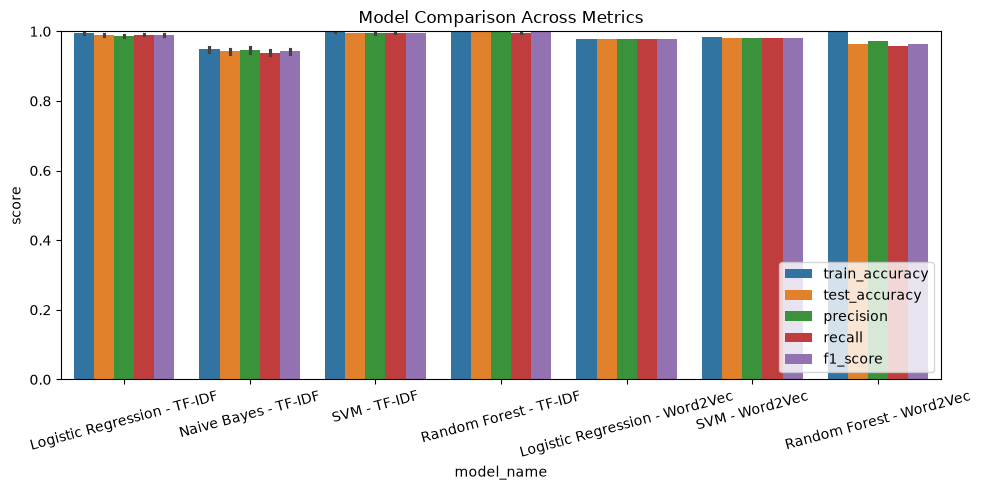

In [40]:
# --- Bar plot comparing metrics across models ---
metrics_to_plot = ['train_accuracy', 'test_accuracy', 'precision', 'recall', 'f1_score']
plot_df = results_df.melt(id_vars='model_name', value_vars=metrics_to_plot,
                           var_name='metric', value_name='score')

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='model_name', y='score', hue='metric')
plt.title('Model Comparison Across Metrics')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


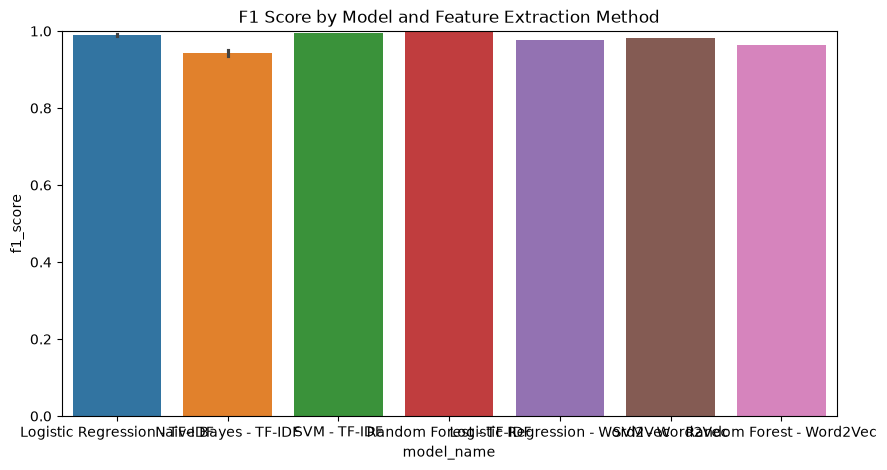

In [45]:
#--- Grouped bar plot: F1 score by model, grouped by feature method ---
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='model_name', y='f1_score', hue='model_name')
plt.title('F1 Score by Model and Feature Extraction Method')
plt.ylim(0,1)
plt.show()

In [42]:
# # --- Confusion matrices side by side ---
# fig, axes = plt.subplots(1, len(results_df), figsize=(5 * len(results_df), 4))
# if len(results_df) == 1:
#     axes = [axes]

# for ax, r in zip(axes, results_df):
#     sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax)
#     ax.set_title(r['model_name'])
#     ax.set_xlabel('Predicted')
#     ax.set_ylabel('Actual')

# plt.tight_layout()
# plt.show()


In [ ]:
# --- Best model selection ---
best_row = results_df.iloc[0]
print(f"Best model based on F1 Score: {best_row['model_name']} "
      f"(F1={best_row['f1_score']:.4f}, Accuracy={best_row['accuracy']:.4f})")
